In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

# Carregar todos os anos
PASTA = Path('../data/processed/sinan')

dfs = []
for arq in sorted(PASTA.glob('*.parquet')):
    df = pd.read_parquet(arq)
    df['ano'] = int(arq.stem.split('_')[-1])
    dfs.append(df)
    print(f"✅ {arq.name}: {len(df):,} registros, {df.shape[1]} colunas")

dengue = pd.concat(dfs, ignore_index=True)
print(f"\n🦟 Dataset completo: {len(dengue):,} registros | {dengue.shape[1]} colunas")

✅ dengue_mt_2018.parquet: 10,131 registros, 120 colunas
✅ dengue_mt_2019.parquet: 17,855 registros, 120 colunas
✅ dengue_mt_2020.parquet: 47,631 registros, 122 colunas
✅ dengue_mt_2021.parquet: 34,174 registros, 122 colunas
✅ dengue_mt_2022.parquet: 35,341 registros, 122 colunas
✅ dengue_mt_2023.parquet: 28,605 registros, 122 colunas
✅ dengue_mt_2024.parquet: 42,742 registros, 122 colunas

🦟 Dataset completo: 216,479 registros | 123 colunas


In [2]:
# Visão geral do dataset
print("📊 SHAPE:", dengue.shape)
print("\n📋 PRIMEIRAS LINHAS:")
dengue.head(3)

📊 SHAPE: (216479, 123)

📋 PRIMEIRAS LINHAS:


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,DT_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,...,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,CS_FLXRET,FLXRECEBI,ano,ANO_NASC,DT_DIGITA,MIGRADO_W
0,2,A90,2018-03-23,201812,2018,51,510180,1580,7761929,2018-03-18,201812,19810111,4037,M,6,4,,14,140010,,1,20180323,,1,2,...,,,,,,,,,,,,,,,,,,2,,1,,2018,<NA>,<NA>,<NA>
1,2,A90,2018-08-11,201832,2018,51,510263,1585,2655802,2018-07-30,201831,19591116,4058,M,6,1,6,43,430080,1608,1,20180811,782310,1,1,...,,,,,,,,,,,,,,,,,,2,,1,,2018,<NA>,<NA>,<NA>
2,2,A90,2018-11-23,201847,2018,51,510180,1580,7761929,2018-11-22,201847,19801215,4037,M,6,2,5,42,420820,1550,1,20181123,782510,2,1,...,,,,,,,,,,,,,,,,,,2,,1,,2018,<NA>,<NA>,<NA>


In [3]:
# Tipos de dados e valores nulos
print("📋 TIPOS DE DADOS E NULOS:\n")
resumo = pd.DataFrame({
    'dtype': dengue.dtypes,
    'nulos': dengue.isnull().sum(),
    'pct_nulo': (dengue.isnull().sum() / len(dengue) * 100).round(1),
    'unique': dengue.nunique()
})
print(resumo.to_string())

📋 TIPOS DE DADOS E NULOS:

             dtype   nulos  pct_nulo  unique
TP_NOT      string       0       0.0       1
ID_AGRAVO   string       0       0.0       1
DT_NOTIFIC  object       0       0.0    2552
SEM_NOT     string       0       0.0     365
NU_ANO      string       0       0.0       8
SG_UF_NOT   string       0       0.0       1
ID_MUNICIP  string       0       0.0     140
ID_REGIONA  string       0       0.0      16
ID_UNIDADE  string       0       0.0    1618
DT_SIN_PRI  object       0       0.0    2802
SEM_PRI     string       0       0.0     586
DT_NASC     string  188493      87.1   16352
NU_IDADE_N  string       0       0.0     173
CS_SEXO     string       0       0.0       3
CS_GESTANT  string       0       0.0       9
CS_RACA     string       0       0.0       7
CS_ESCOL_N  string       0       0.0      13
SG_UF       string       0       0.0      26
ID_MN_RESI  string       0       0.0     643
ID_RG_RESI  string       0       0.0     202
ID_PAIS     string       0  

In [4]:
# Colunas-chave para o projeto de predição
print("📅 DATAS — valores únicos:")
print("DT_NOTIFIC:", dengue['DT_NOTIFIC'].dtype, dengue['DT_NOTIFIC'].head(3).tolist())
print("DT_SIN_PRI:", dengue['DT_SIN_PRI'].dtype, dengue['DT_SIN_PRI'].head(3).tolist())

print("\n🏙️ MUNICÍPIOS (top 10):")
print(dengue['ID_MUNICIP'].value_counts().head(10))

print("\n🦟 CLASSIFICAÇÃO FINAL:")
print(dengue['CLASSI_FIN'].value_counts())

print("\n📈 EVOLUÇÃO (desfecho):")
print(dengue['EVOLUCAO'].value_counts())

print("\n🏥 HOSPITALIZAÇÃO:")
print(dengue['HOSPITALIZ'].value_counts())

📅 DATAS — valores únicos:
DT_NOTIFIC: object [datetime.date(2018, 3, 23), datetime.date(2018, 8, 11), datetime.date(2018, 11, 23)]
DT_SIN_PRI: object [datetime.date(2018, 3, 18), datetime.date(2018, 7, 30), datetime.date(2018, 11, 22)]

🏙️ MUNICÍPIOS (top 10):
ID_MUNICIP
510790    19741
510704    13821
510792    12373
510340     9623
510622     9403
510795     8965
510760     7375
510525     6424
510025     5738
510250     5520
Name: count, dtype: int64[pyarrow]

🦟 CLASSIFICAÇÃO FINAL:
CLASSI_FIN
10    163534
5      33895
8      15870
11      2711
12       280
         129
          60
Name: count, dtype: int64[pyarrow]

📈 EVOLUÇÃO (desfecho):
EVOLUCAO
1    185619
      19693
       5545
9      5359
3       137
2       111
4        15
Name: count, dtype: int64[pyarrow]

🏥 HOSPITALIZAÇÃO:
HOSPITALIZ
2    166538
      27017
1     14003
       5644
9      3277
Name: count, dtype: int64[pyarrow]


In [5]:
# Decodificar classificação final e filtrar municípios de interesse
# Códigos SINAN: 10=Dengue, 11=Dengue c/ sinais alarme, 12=Dengue grave, 5=Descartado, 8=Inconclusivo

classi_map = {
    '10': 'Dengue',
    '11': 'Dengue c/ Alarme',
    '12': 'Dengue Grave',
    '5':  'Descartado',
    '8':  'Inconclusivo',
    '':   'Sem classificação'
}

evolucao_map = {
    '1': 'Cura',
    '2': 'Óbito por dengue',
    '3': 'Óbito por outra causa',
    '4': 'Óbito em investigação',
    '9': 'Ignorado',
    '':  'Sem informação'
}

# Municípios de interesse
# Cuiabá = 510340, Várzea Grande = 510790
print("🏙️ CUIABÁ (510340):", dengue[dengue['ID_MUNICIP']=='510340'].shape[0], "registros")
print("🏙️ VÁRZEA GRANDE (510790):", dengue[dengue['ID_MUNICIP']=='510790'].shape[0], "registros")

# Filtrar apenas casos confirmados de dengue
dengue['CLASSI_NOME'] = dengue['CLASSI_FIN'].map(classi_map).fillna('Outro')
dengue['EVOLUCAO_NOME'] = dengue['EVOLUCAO'].map(evolucao_map).fillna('Sem informação')

print("\n🦟 CASOS CONFIRMADOS DE DENGUE:")
confirmados = dengue[dengue['CLASSI_FIN'].isin(['10','11','12'])]
print(f"Total: {len(confirmados):,} registros ({len(confirmados)/len(dengue)*100:.1f}% do total)")

print("\nPor classificação:")
print(confirmados['CLASSI_NOME'].value_counts())

🏙️ CUIABÁ (510340): 9623 registros
🏙️ VÁRZEA GRANDE (510790): 19741 registros

🦟 CASOS CONFIRMADOS DE DENGUE:
Total: 166,525 registros (76.9% do total)

Por classificação:
CLASSI_NOME
Dengue              163534
Dengue c/ Alarme      2711
Dengue Grave           280
Name: count, dtype: int64


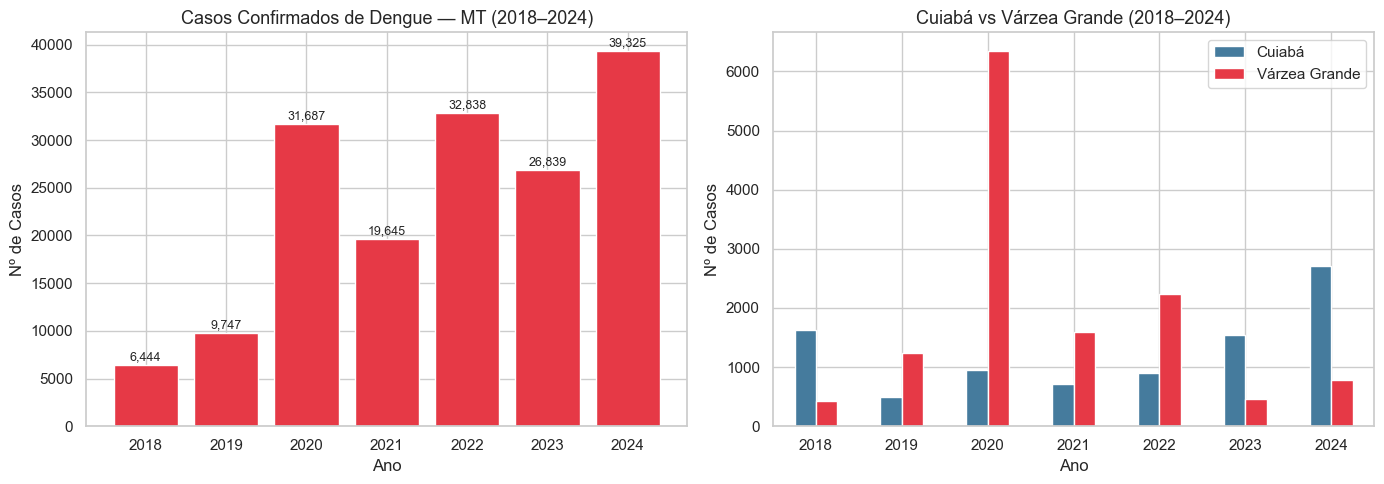

✅ Gráfico salvo em reports/fig01_casos_por_ano.png


In [6]:
# Converter datas
dengue['DT_NOTIFIC'] = pd.to_datetime(dengue['DT_NOTIFIC'])
dengue['DT_SIN_PRI'] = pd.to_datetime(dengue['DT_SIN_PRI'])

# Filtrar confirmados
confirmados = dengue[dengue['CLASSI_FIN'].isin(['10','11','12'])].copy()

# Casos por ano
casos_ano = confirmados.groupby('ano').size().reset_index(name='casos')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1 — Casos por ano (MT)
axes[0].bar(casos_ano['ano'], casos_ano['casos'], color='#e63946', edgecolor='white')
axes[0].set_title('Casos Confirmados de Dengue — MT (2018–2024)', fontsize=13)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Nº de Casos')
for i, row in casos_ano.iterrows():
    axes[0].text(row['ano'], row['casos'] + 500, f"{row['casos']:,}", 
                 ha='center', fontsize=9)

# 2 — Cuiabá vs Várzea Grande
cba_vg = confirmados[confirmados['ID_MUNICIP'].isin(['510340','510790'])]
cba_vg_ano = cba_vg.groupby(['ano','ID_MUNICIP']).size().unstack()
cba_vg_ano.columns = ['Cuiabá', 'Várzea Grande']
cba_vg_ano.plot(kind='bar', ax=axes[1], color=['#457b9d','#e63946'], edgecolor='white')
axes[1].set_title('Cuiabá vs Várzea Grande (2018–2024)', fontsize=13)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Nº de Casos')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/fig01_casos_por_ano.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports/fig01_casos_por_ano.png")

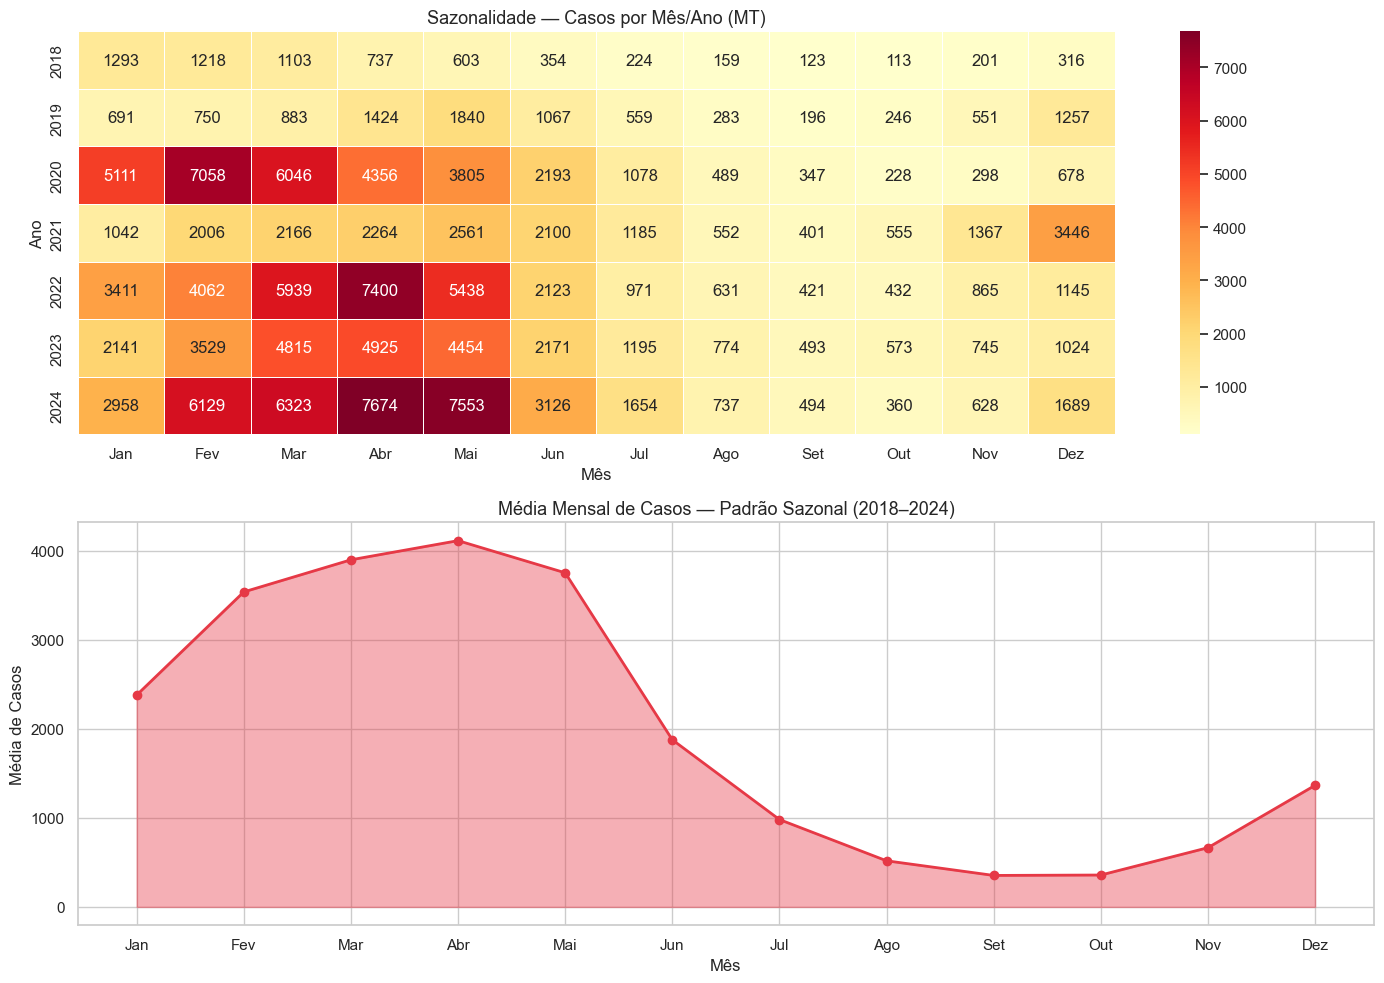

✅ Gráfico salvo em reports/fig02_sazonalidade.png


In [7]:
# Sazonalidade — casos por mês
confirmados['mes'] = confirmados['DT_NOTIFIC'].dt.month
confirmados['mes_nome'] = confirmados['DT_NOTIFIC'].dt.strftime('%b')

casos_mes_ano = confirmados.groupby(['ano','mes']).size().unstack(level=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1 — Heatmap de sazonalidade
import seaborn as sns
sns.heatmap(casos_mes_ano.T, 
            annot=True, fmt='.0f', 
            cmap='YlOrRd',
            ax=axes[0],
            linewidths=0.5)
axes[0].set_title('Sazonalidade — Casos por Mês/Ano (MT)', fontsize=13)
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Ano')
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
axes[0].set_xticklabels(meses)

# 2 — Média mensal acumulada (padrão sazonal geral)
media_mes = confirmados.groupby('mes').size() / confirmados['ano'].nunique()
axes[1].fill_between(range(1,13), media_mes.values, alpha=0.4, color='#e63946')
axes[1].plot(range(1,13), media_mes.values, color='#e63946', linewidth=2, marker='o')
axes[1].set_title('Média Mensal de Casos — Padrão Sazonal (2018–2024)', fontsize=13)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(meses)
axes[1].set_ylabel('Média de Casos')
axes[1].set_xlabel('Mês')

plt.tight_layout()
plt.savefig('../reports/fig02_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports/fig02_sazonalidade.png")

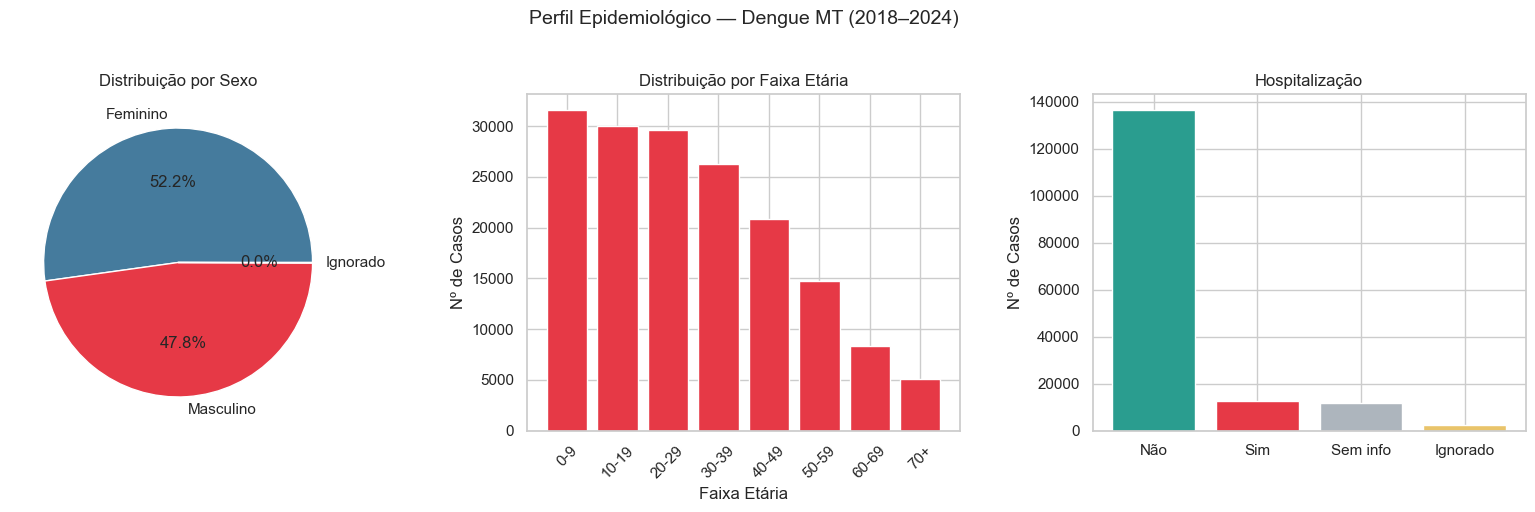

✅ Gráfico salvo em reports/fig03_perfil_epidemiologico.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1 — Sexo
sexo_map = {'M': 'Masculino', 'F': 'Feminino', 'I': 'Ignorado'}
sexo = confirmados['CS_SEXO'].map(sexo_map).value_counts()
axes[0].pie(sexo.values, labels=sexo.index, autopct='%1.1f%%',
            colors=['#457b9d','#e63946','#adb5bd'])
axes[0].set_title('Distribuição por Sexo')

# 2 — Faixa etária
def extrair_idade(valor):
    try:
        v = int(str(valor))
        if v >= 4000:
            return v - 4000
        elif v >= 3000:
            return (v - 3000) / 12
        elif v >= 2000:
            return (v - 2000) / 365
        return None
    except:
        return None

confirmados['IDADE_ANOS'] = confirmados['NU_IDADE_N'].apply(extrair_idade)
bins = [0, 10, 20, 30, 40, 50, 60, 70, 120]
labels_idade = ['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70+']
confirmados['FAIXA_ETARIA'] = pd.cut(confirmados['IDADE_ANOS'], bins=bins, labels=labels_idade)
faixa = confirmados['FAIXA_ETARIA'].value_counts().sort_index()
axes[1].bar(faixa.index, faixa.values, color='#e63946', edgecolor='white')
axes[1].set_title('Distribuição por Faixa Etária')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Nº de Casos')
axes[1].tick_params(axis='x', rotation=45)

# 3 — Hospitalização
hosp_map = {'1': 'Sim', '2': 'Não', '9': 'Ignorado', '': 'Sem info'}
hosp = confirmados['HOSPITALIZ'].map(hosp_map).value_counts()
cores_hosp = ['#2a9d8f','#e63946','#adb5bd','#e9c46a']
axes[2].bar(hosp.index, hosp.values, color=cores_hosp[:len(hosp)], edgecolor='white')
axes[2].set_title('Hospitalização')
axes[2].set_ylabel('Nº de Casos')

plt.suptitle('Perfil Epidemiológico — Dengue MT (2018–2024)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig03_perfil_epidemiologico.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports/fig03_perfil_epidemiologico.png")

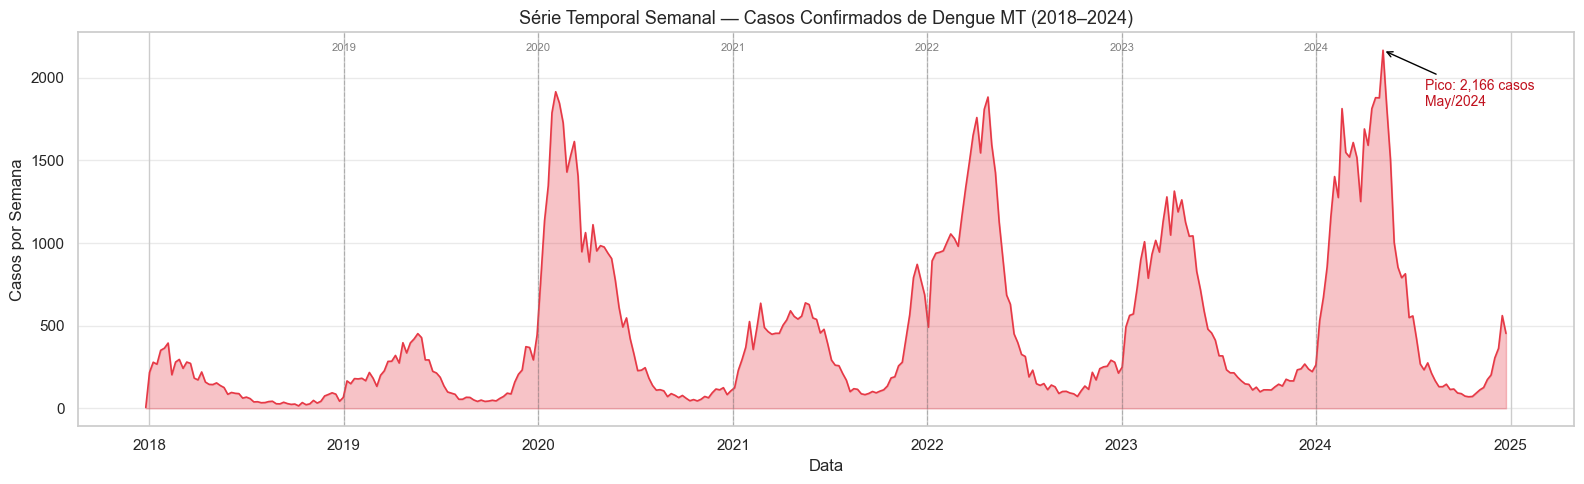

✅ Gráfico salvo em reports/fig04_serie_temporal.png


In [9]:
# Série temporal semanal — base do modelo preditivo
confirmados['semana'] = confirmados['DT_NOTIFIC'].dt.to_period('W').dt.start_time

serie_semanal = confirmados.groupby('semana').size().reset_index(name='casos')

fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(serie_semanal['semana'], serie_semanal['casos'], 
                alpha=0.3, color='#e63946')
ax.plot(serie_semanal['semana'], serie_semanal['casos'], 
        color='#e63946', linewidth=1.2)

# Marcar picos
pico_idx = serie_semanal['casos'].idxmax()
pico = serie_semanal.loc[pico_idx]
ax.annotate(f"Pico: {pico['casos']:,} casos\n{pico['semana'].strftime('%b/%Y')}",
            xy=(pico['semana'], pico['casos']),
            xytext=(30, -40), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='#c1121f')

ax.set_title('Série Temporal Semanal — Casos Confirmados de Dengue MT (2018–2024)', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Casos por Semana')
ax.grid(axis='y', alpha=0.4)

# Linhas verticais por ano
for ano in range(2019, 2025):
    ax.axvline(pd.Timestamp(f'{ano}-01-01'), color='gray', 
               linestyle='--', alpha=0.4, linewidth=0.8)
    ax.text(pd.Timestamp(f'{ano}-01-01'), ax.get_ylim()[1]*0.95, 
            str(ano), ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('../reports/fig04_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports/fig04_serie_temporal.png")